In [150]:
import numpy as np
import matplotlib.pyplot as plt

# physical properties
rho   = 1000.0            # water density kg/m³
mu    = .001              # viscosity Pa·s
k     = 1.0e-10           # permeability m²
g     = 9.81              # gravitation acceleration rate m/s²

# Boundary conditions
ul = 0.1/100/60      # Darcy velocity left Neumann m/s .1 cm/m
hR  = 1.0            # head at the right boundary Dirichlet

# hydraulic conductivity
K = rho * g * k / mu
print("K = ", K, " m/s ")

print("ul =", ul)
print("K =", K)
print("Lx =", Lx)
print("ul/K =", ul/K)

K =  0.0009809999999999999  m/s 
ul = 1.6666666666666667e-05
K = 0.0009809999999999999
Lx = 1
ul/K = 0.016989466530750938


In [151]:
# derived analytical solution for hydraulic head
"""
∇ * (-K ∇ h) = 0
-K d/dx = c = uin =.1
-kh = cx + d
-kh(x) = uin * x + d
h(l)=hk
-Khr = uin * L + d
d= -KhR - uin
-kh (x) = uin * x - KhR - uin
h(x) = -uin/K * x + hR + uin
"""

#analytical hydraulic head
h_x = -ul / K * Nx + hR + ul

In [152]:
# parameters domain 1-D
Nx   = 4         # number of cells
Lx  = 1          # length in m
dx  = Lx / Nx

# transmissibility matrix
Kmat = K * np.ones(Nx)
print ("Kmat = ", Kmat, " m/s ")

TL = np.full(Nx, np.nan)
TL[0] = 0 # due to flux boundary condition at the left boundary
TL[1:Nx] = 2 / dx * (1 / Kmat[:Nx-1] + 1 / Kmat[1:Nx]) ** -1

TR = np.full(Nx, np.nan)
TR[Nx-1] = 2 / dx * (1 / Kmat[Nx-1]) ** -1
TR[0:Nx-1] = 2 / dx * (1 / Kmat[:Nx-1] + 1 / Kmat[1:Nx]) ** -1

TC   = TL + TR
Tmat = np.diag(TC) + np.diag(-TL[1:Nx], -1) + np.diag(-TR[:Nx-1], 1)
print("Tmat = ", Tmat, " m/s ")

Kmat =  [0.000981 0.000981 0.000981 0.000981]  m/s 
Tmat =  [[ 0.003924 -0.003924  0.        0.      ]
 [-0.003924  0.007848 -0.003924  0.      ]
 [ 0.       -0.003924  0.007848 -0.003924]
 [ 0.        0.       -0.003924  0.011772]]  m/s 


In [153]:
#right-hand side vector
b = np.zeros((Nx, 1))
b[0] = ul
b[Nx-1] = TR[Nx-1] * hR #right
print("Right-hand side vector", b)

#hydraulic heads
h = np.linalg.solve(Tmat, b)
print("Hydraulic heads:", h)


Right-hand side vector [[1.66666667e-05]
 [0.00000000e+00]
 [0.00000000e+00]
 [7.84800000e-03]]
Hydraulic heads: [[1.01486578]
 [1.01061842]
 [1.00637105]
 [1.00212368]]


In [154]:
# N = 1000 version
N1000 = 1000
dx1000 = Lx / N1000

# Transmissibility matrix
K = rho * g * k / mu
Kmat = K * np.ones(N1000)

TL = np.full(N1000, np.nan)
TL[:1] = 0 # due to flux boundary condition at the left boundary
TL[1:N1000] = 2/dx1000 * (1/Kmat[:N1000-1] + 1/Kmat[1:N1000])**(-1)

TR = np.full(N1000, np.nan)
TR[N1000-1] = 2/dx1000 * (1/Kmat[N1000-1])**(-1)
TR[0:N1000-1] = 2/dx1000 * (1/Kmat[:N1000-1] + 1/Kmat[1:N1000])**(-1)

TC = TL + TR

Tmat1000 = np.diag(TC) + np.diag(-TL[1:N1000], -1) + np.diag(-TR[0:N1000-1], 1)


b1000 = np.zeros((N1000, 1))
b1000[0] = ul
b1000[N1000-1] = TR[N1000-1] * hR

#hydraulic heads
h1000 = np.linalg.solve(Tmat1000, b1000)

[1.01486578 1.01061842 1.00637105 1.00212368]


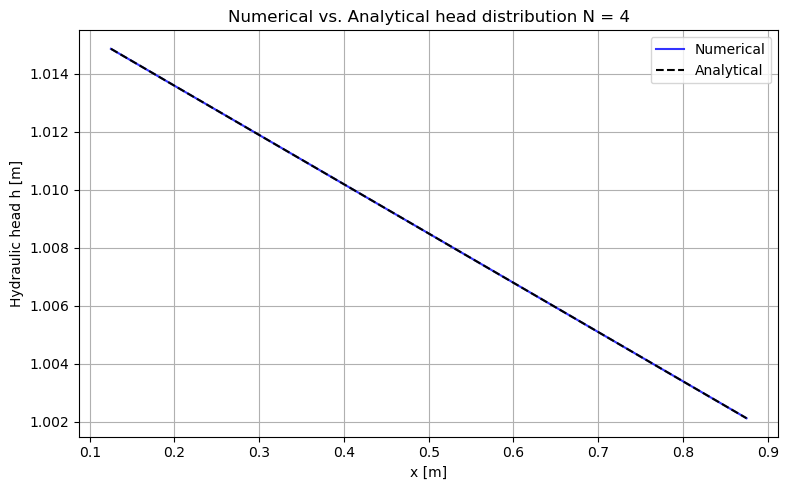

In [155]:
#plot hydraulic-head distribution with the analytical solution
h_num = np.linalg.solve(Tmat, b).flatten()

x_centres = (np.arange(0.5, Nx + 0.5)) * dx

h_xplot = hR + ul / K * (Lx - x_centres)
print(h_xplot)

plt.figure(figsize=(8,5))
plt.plot(x_centres, h_num, 'b-', alpha=0.8, label='Numerical')
plt.plot(x_centres, h_xplot, 'k--', label='Analytical')
plt.xlabel('x [m]')
plt.ylabel('Hydraulic head h [m]')
plt.title('Numerical vs. Analytical head distribution N = 4')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

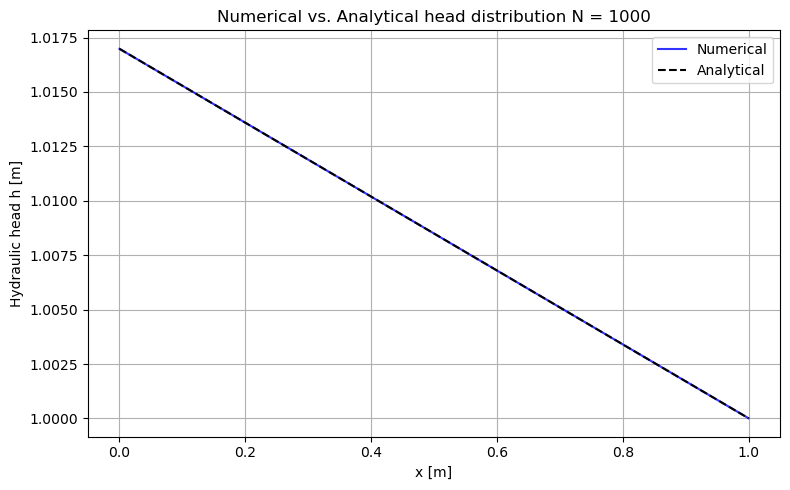

h_num1000[:5] = [1.01698097 1.01696398 1.01694699 1.01693    1.01691301]
h_xplot1000[:5] = [1.01698097 1.01696398 1.01694699 1.01693    1.01691301]
h_num1000[-5:] = [1.00007645 1.00005946 1.00004247 1.00002548 1.00000849]
h_xplot1000[-5:] = [1.00007645 1.00005946 1.00004247 1.00002548 1.00000849]


In [156]:
#plot hydraulic-head distribution with the analytical solution 1000 version
h_num1000 = np.linalg.solve(Tmat1000, b1000).flatten()

x_centres1000 = (np.arange(0.5, N1000 + 0.5)) * dx1000

h_xplot1000 = hR + ul / K * (Lx - x_centres1000)


plt.figure(figsize=(8,5))
plt.plot(x_centres1000, h_num1000, 'b-', alpha=0.8, label='Numerical')
plt.plot(x_centres1000, h_xplot1000, 'k--', label='Analytical')
plt.xlabel('x [m]')
plt.ylabel('Hydraulic head h [m]')
plt.title('Numerical vs. Analytical head distribution N = 1000')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("h_num1000[:5] =", h_num1000[:5])
print("h_xplot1000[:5] =", h_xplot1000[:5])
print("h_num1000[-5:] =", h_num1000[-5:])
print("h_xplot1000[-5:] =", h_xplot1000[-5:])